Barplot pour visualier les configurations

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as mticker
import os
import seaborn as sns

In [2]:

print(os.getcwd())

/autofs/unityaccount/cremi/leanguye/projet-deep-learning-m1/resnet18/src/resnet18_RGB_MS_HS/results


In [3]:
os.makedirs("figures", exist_ok=True )

le chemin est relatif à la position DU NOTEBOOK dans le dossier de travail. Pas à pwd dans le terminal.

In [20]:
#import des résultats

grid_par_classe_aug = pd.read_csv("grid_search_results_par_classe_data_augmentation_RGB_MS_HS.csv") 

In [21]:
#pour sélectionner les configs avec 50 epochs / 100 epochs

grid_par_classe_aug_50 = grid_par_classe_aug.head(32)
grid_par_classe_aug_100 = grid_par_classe_aug.tail(32)

In [22]:
config_par_classe_aug_50 = grid_par_classe_aug_50['config'].str.extract(r'(config\d+)') [0].str.replace("config", "c")
config_par_classe_aug_100 = grid_par_classe_aug_100['config'].str.extract(r'(config\d+)') [0].str.replace("config", "c")
#autre manière de faire : labels = [f"c{i}" for i in range(len(df_random))] mais ne permet pas de s'assurer que c'est la bonne config

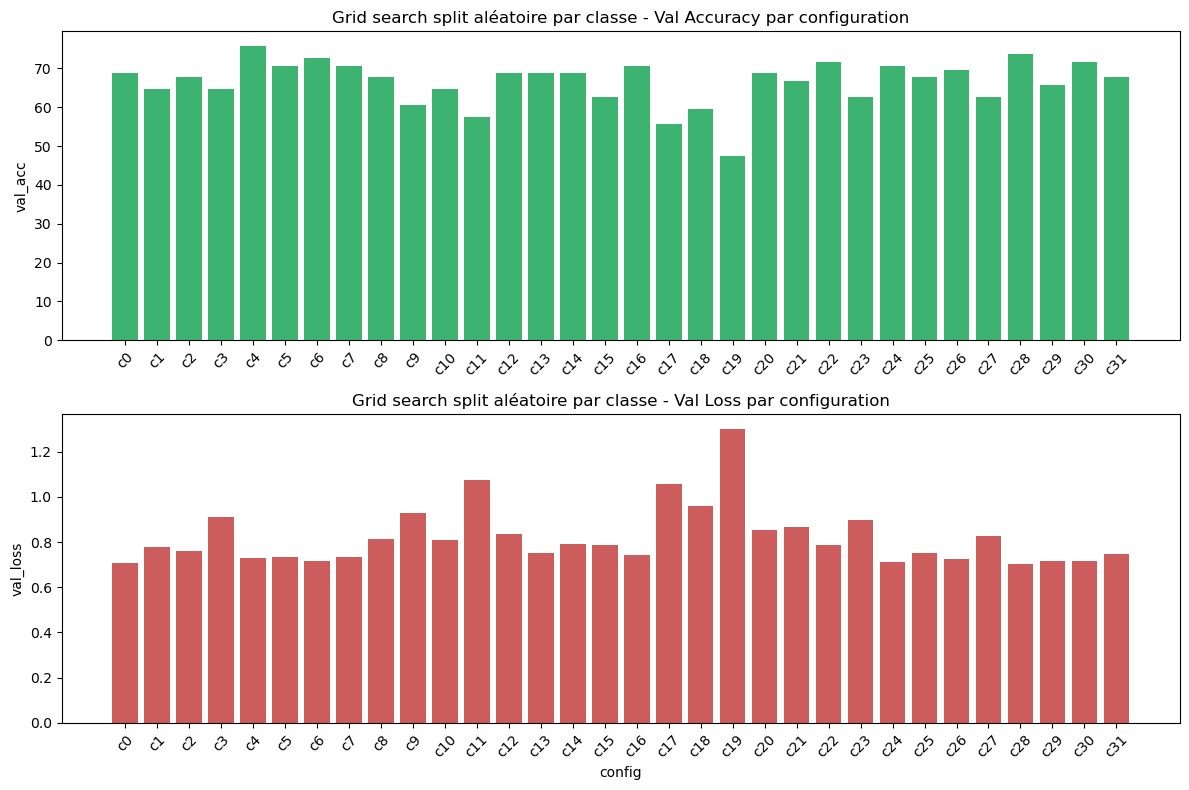

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

#Accuracy

axes[0].bar(config_par_classe_aug_50, grid_par_classe_aug_50['val_acc'], color="mediumseagreen")
axes[0].set_title("Grid search split aléatoire par classe - Val Accuracy par configuration")
axes[0].set_ylabel("val_acc")
axes[0].tick_params(axis='x', rotation=45)


axes[1].bar(config_par_classe_aug_50, grid_par_classe_aug_50['val_loss'], color='indianred')
axes[1].set_title("Grid search split aléatoire par classe - Val Loss par configuration")
axes[1].set_xlabel("config")
axes[1].set_ylabel("val_loss")
axes[1].tick_params(axis='x', rotation=45)

#plt.title("Grid search split aléatoire par classe - Val Accuracy/Loss par configuration")

plt.tight_layout() #pour que les labels ne se chevauchent pas
plt.show()



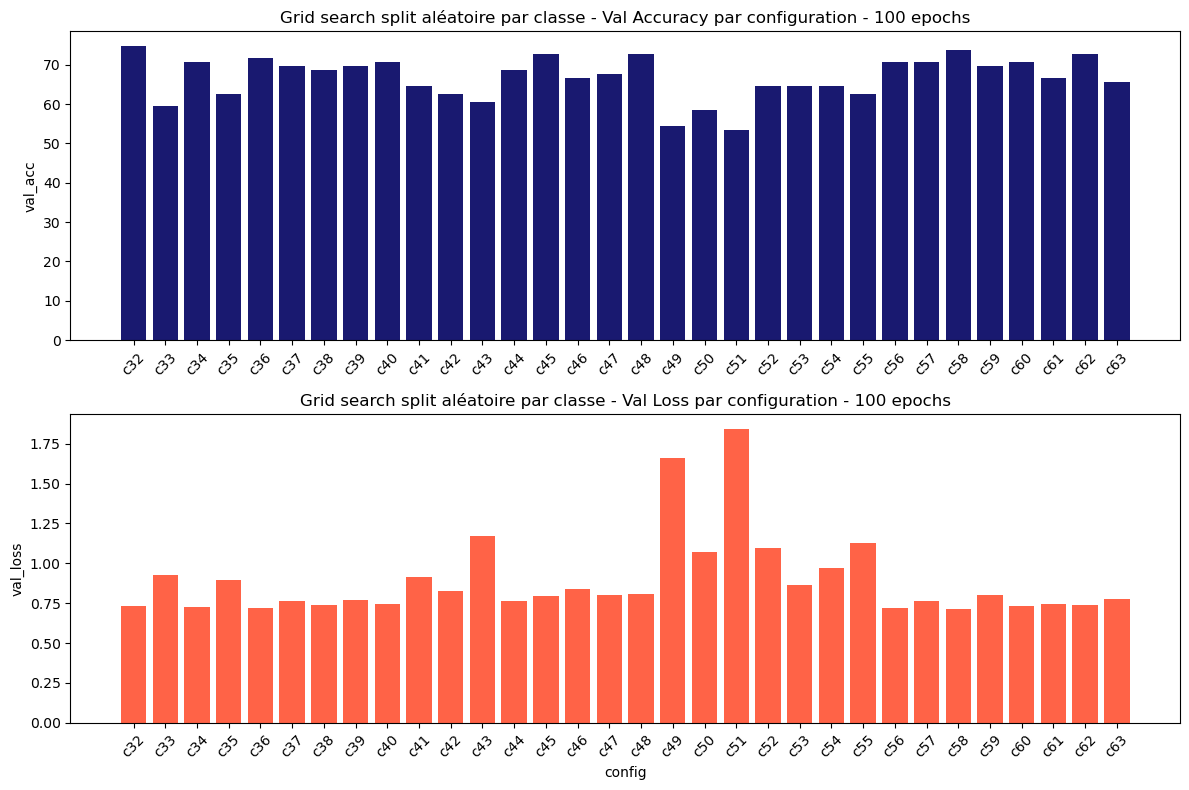

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

#Accuracy

axes[0].bar(config_par_classe_aug_100, grid_par_classe_aug_100['val_acc'], color="midnightblue")
axes[0].set_title("Grid search split aléatoire par classe - Val Accuracy par configuration - 100 epochs")
axes[0].set_ylabel("val_acc")
axes[0].tick_params(axis='x', rotation=45)


axes[1].bar(config_par_classe_aug_100, grid_par_classe_aug_100['val_loss'], color='tomato')
axes[1].set_title("Grid search split aléatoire par classe - Val Loss par configuration - 100 epochs")
axes[1].set_xlabel("config")
axes[1].set_ylabel("val_loss")
axes[1].tick_params(axis='x', rotation=45)

#plt.title("Grid search split aléatoire par classe - Val Accuracy/Loss par configuration")

plt.tight_layout() #pour que les labels ne se chevauchent pas
plt.show()

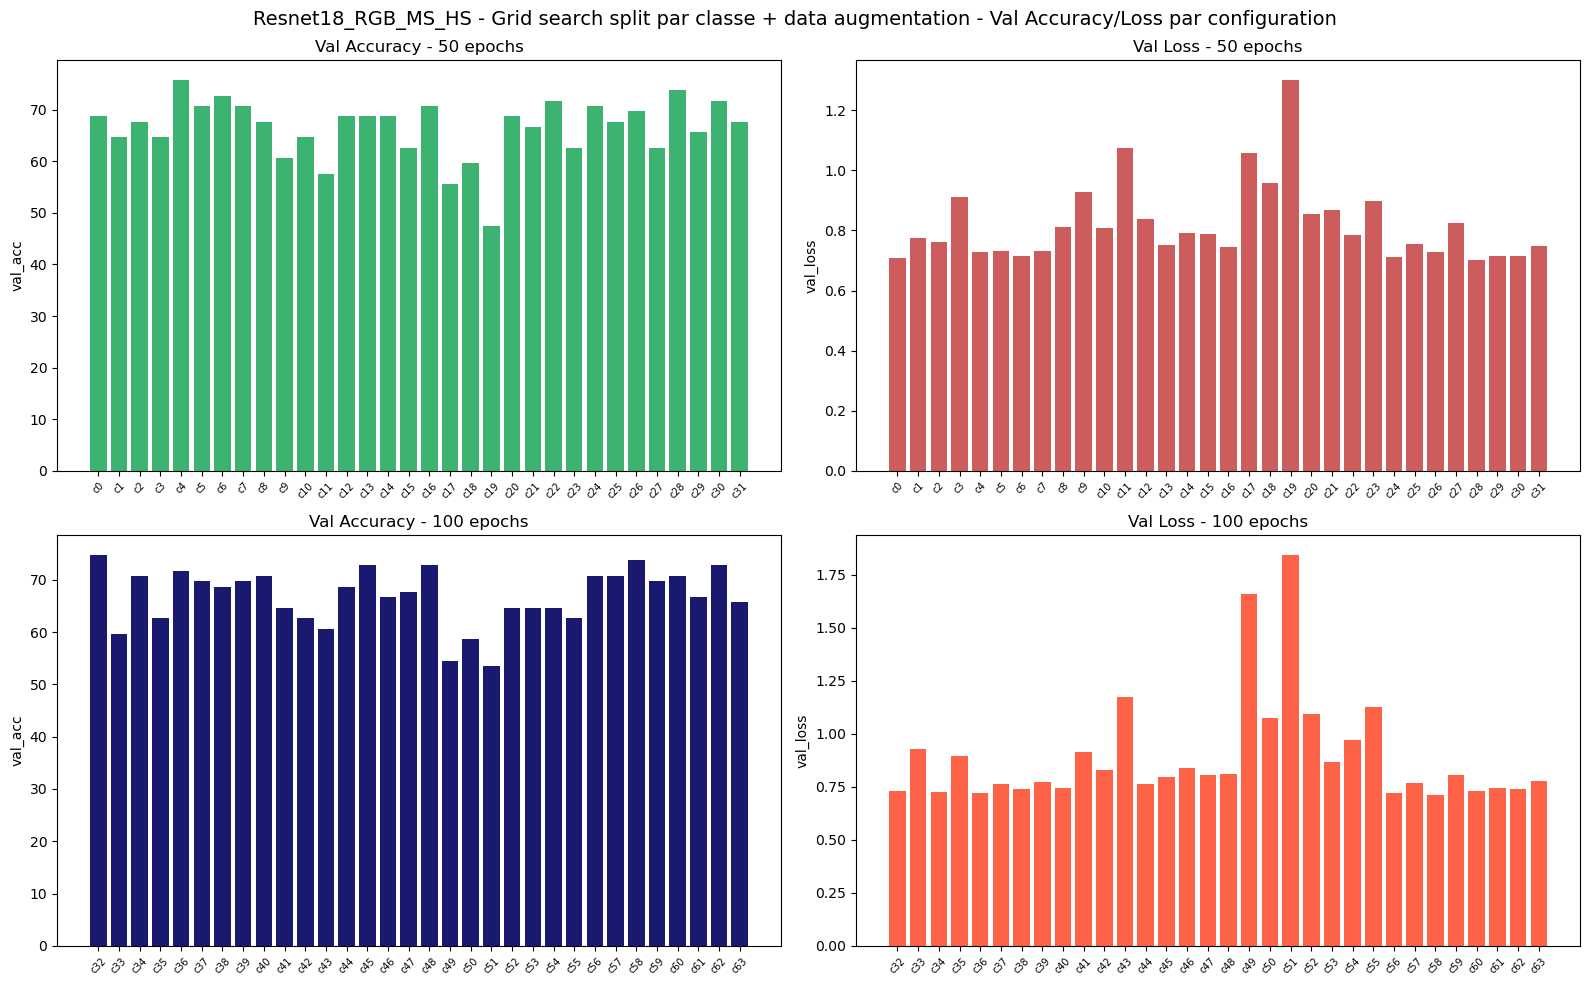

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Resnet18_RGB_MS_HS - Grid search split par classe + data augmentation - Val Accuracy/Loss par configuration", fontsize=14)

# 50 epochs
axes[0,0].bar(config_par_classe_aug_50, grid_par_classe_aug_50['val_acc'], color="mediumseagreen")
axes[0,0].set_title("Val Accuracy - 50 epochs")
axes[0,0].set_ylabel("val_acc")
axes[0,0].tick_params(axis='x', rotation=45, labelsize=7)

axes[0,1].bar(config_par_classe_aug_50, grid_par_classe_aug_50['val_loss'], color='indianred')
axes[0,1].set_title("Val Loss - 50 epochs")
axes[0,1].set_ylabel("val_loss")
axes[0,1].tick_params(axis='x', rotation=45, labelsize=7)

# 100 epochs
axes[1,0].bar(config_par_classe_aug_100, grid_par_classe_aug_100['val_acc'], color="midnightblue")
axes[1,0].set_title("Val Accuracy - 100 epochs")
axes[1,0].set_ylabel("val_acc")
axes[1,0].tick_params(axis='x', rotation=45, labelsize=7)

axes[1,1].bar(config_par_classe_aug_100, grid_par_classe_aug_100['val_loss'], color='tomato')
axes[1,1].set_title("Val Loss - 100 epochs")
axes[1,1].set_ylabel("val_loss")
axes[1,1].tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.savefig("figures/grid_search_18_RGB_MS_HS.png", dpi=150, bbox_inches="tight")
plt.show()

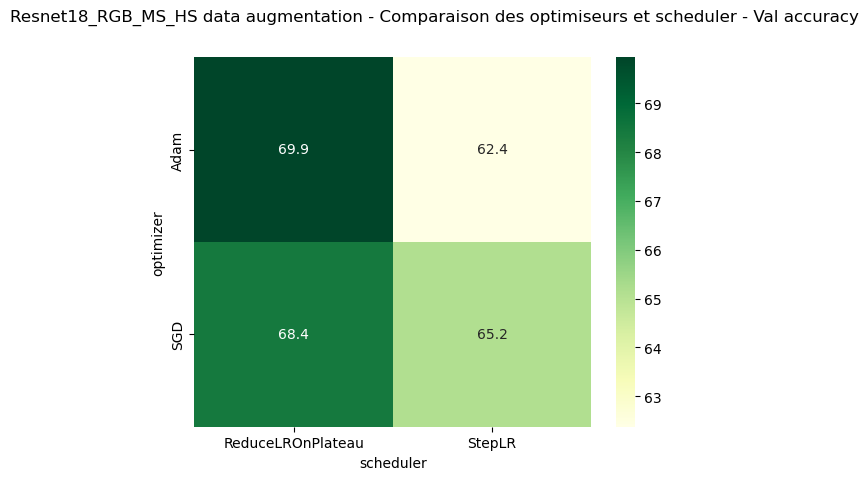

In [11]:
""" Heatmap des hyperparamètres
Visualiser quelle combinaison optimizer x scheduler """
plt.figure()
plt.suptitle("Resnet18_RGB_MS_HS data augmentation - Comparaison des optimiseurs et scheduler - Val accuracy")
pivot = grid_par_classe_aug_50.pivot_table(values='val_acc', index='optimizer', columns='scheduler')
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGn")
plt.savefig("figures/heatmap_optimiseur_18_RGB_MS_HS.png", dpi=150, bbox_inches="tight" )

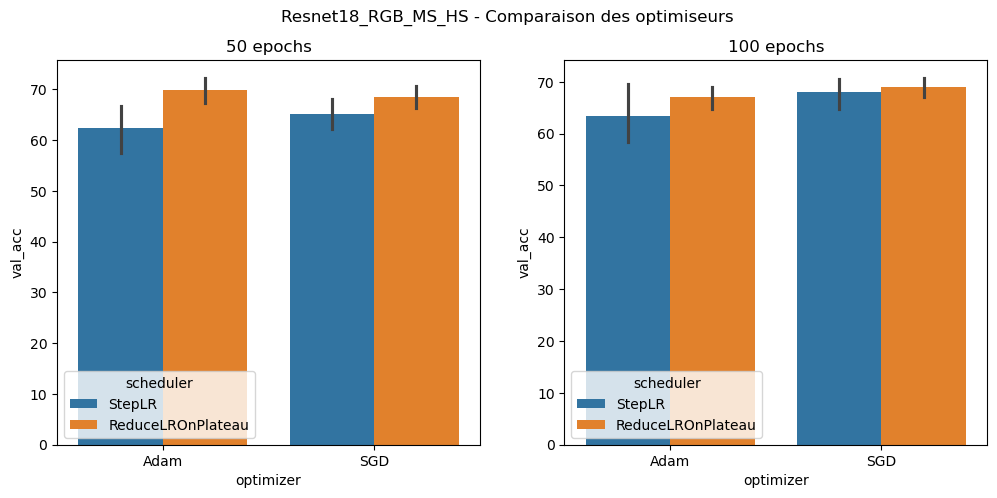

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.suptitle("Resnet18_RGB_MS_HS - Comparaison des optimiseurs")
axe1 = axes[0]
sns.barplot(data=grid_par_classe_aug_50, x='optimizer', y='val_acc', hue='scheduler', ax=axe1)
axe1.set_title("50 epochs")

axe2 = axes[1]
sns.barplot(data=grid_par_classe_aug_100, x='optimizer', y='val_acc', hue='scheduler', ax=axe2)
axe2.set_title("100 epochs")
plt.savefig("figures/comparaison des optimiseurs_18_RGB_MS_HS.png", dpi=150, bbox_inches="tight")

plt.show()

/tmp/cache-leanguye/ipykernel_4102303/2657996818.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_par_classe_aug_50['epochs'] = 50
/tmp/cache-leanguye/ipykernel_4102303/2657996818.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_par_classe_aug_100['epochs'] = 100


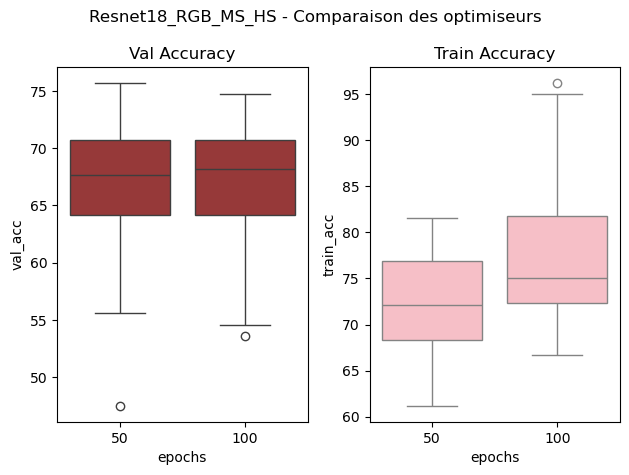

In [13]:
# Ajouter la colonne epochs
grid_par_classe_aug_50['epochs'] = 50
grid_par_classe_aug_100['epochs'] = 100

# Combiner
combined_par_classe_aug = pd.concat([grid_par_classe_aug_50, grid_par_classe_aug_100])

fig, axes = plt.subplots(1,2)

plt.suptitle("Resnet18_RGB_MS_HS - Comparaison des optimiseurs")

axe1 = axes[0]
sns.boxplot(data=combined_par_classe_aug, x='epochs', y='val_acc', color="brown", ax=axe1)
axe1.set_title("Val Accuracy")

axe2 = axes[1]
sns.boxplot(data=combined_par_classe_aug, x='epochs', y='train_acc', color="lightpink", ax=axe2)
axe2.set_title("Train Accuracy")


plt.tight_layout()
plt.savefig("figures/comparaison_epochs_val_train_acc18_RGB_MS_HS.png", dpi=150, bbox_inches="tight")
plt.show()



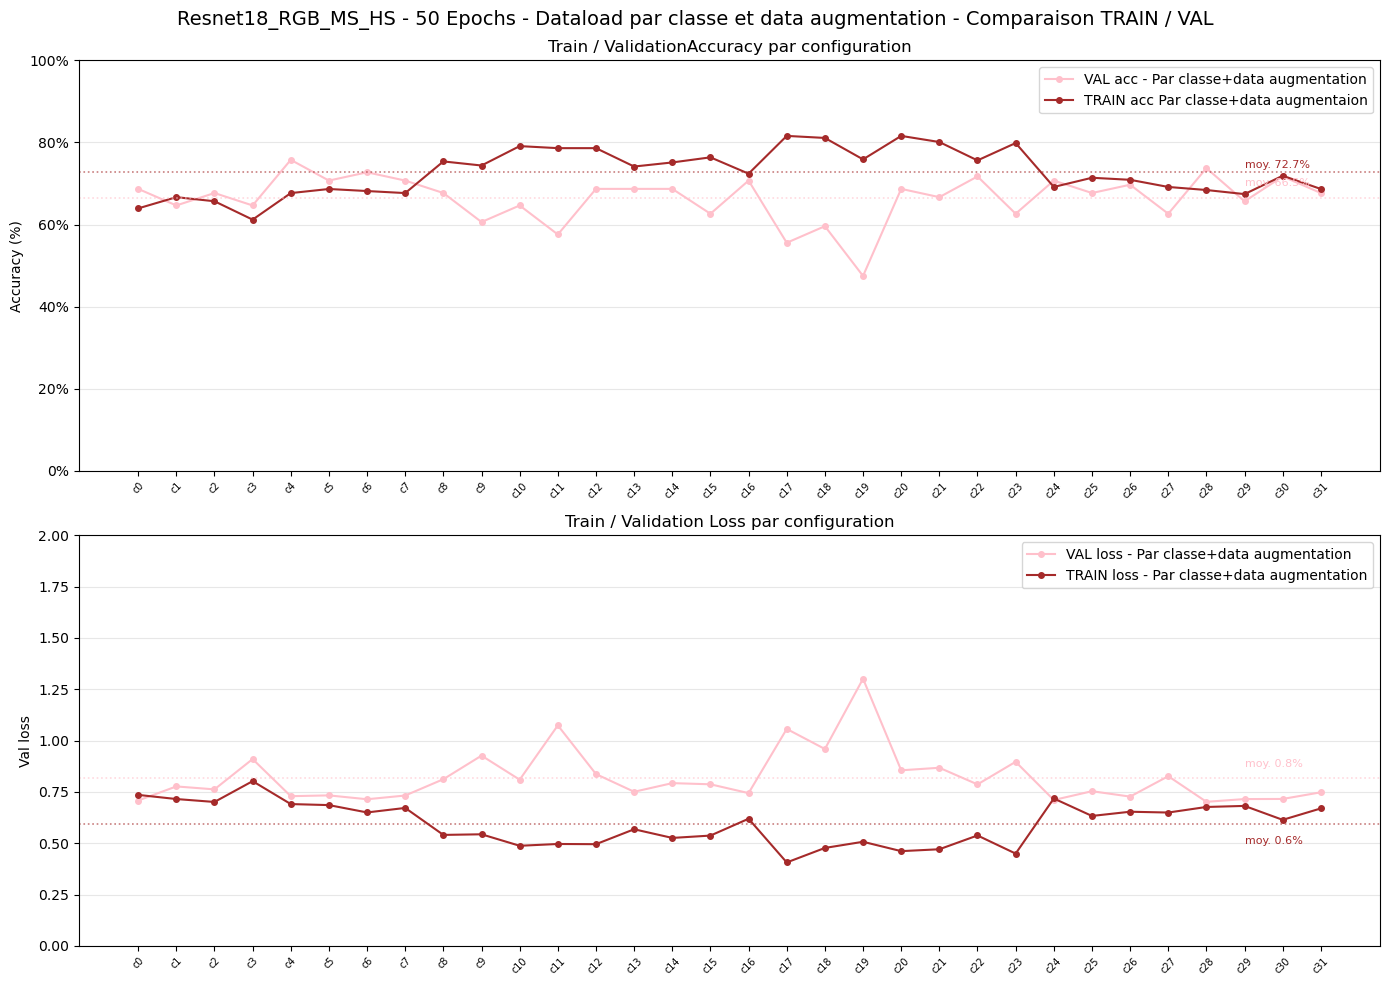

In [14]:
labels = [f"c{i}" for i in range(len(grid_par_classe_aug_50))]

# --- Figure 1 : val_acc comparaison ---

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Resnet18_RGB_MS_HS - 50 Epochs - Dataload par classe et data augmentation - Comparaison TRAIN / VAL", fontsize=14)

ax1 = axes[0]
ax1.plot(labels, grid_par_classe_aug_50["val_acc"],  color="pink", linestyle="-",  marker="o", markersize=4, label="VAL acc - Par classe+data augmentation")
ax1.plot(labels, grid_par_classe_aug_50["train_acc"],  color="brown", linestyle="-",  marker="o", markersize=4, label="TRAIN acc Par classe+data augmentaion")
ax1.axhline(grid_par_classe_aug_50["val_acc"].mean(),  color="pink", linestyle=":", alpha=0.6, linewidth=1.2)
ax1.axhline(grid_par_classe_aug_50["train_acc"].mean(),  color="brown", linestyle=":", alpha=0.6, linewidth=1.2)
ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim(0, 100)
ax1.set_title("Train / ValidationAccuracy par configuration")
ax1.legend()
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45, fontsize=7)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax1.grid(axis="y", alpha=0.3)

# Annotations moyennes
ax1.annotate(f"moy. {grid_par_classe_aug_50['train_acc'].mean():.1f}%", xy=(31, grid_par_classe_aug_50["train_acc"].mean()),
             xytext=(29, grid_par_classe_aug_50["train_acc"].mean() + 1), color="brown", fontsize=8)
ax1.annotate(f"moy. {grid_par_classe_aug_50['val_acc'].mean():.1f}%", xy=(31, grid_par_classe_aug_50["val_acc"].mean()), #défini les coordonnées du graphique
             xytext=(29, grid_par_classe_aug_50["val_acc"].mean() + 3), color="pink", fontsize=8) #défini les coordonnées précises du graphique ou doit s'afficher le texte

# --- Figure 2 : val_loss comparaison ---
ax2 = axes[1]
ax2.plot(labels, grid_par_classe_aug_50["val_loss"],  color="pink", linestyle="-",  marker="o", markersize=4, label="VAL loss - Par classe+data augmentation")
ax2.plot(labels, grid_par_classe_aug_50["train_loss"],  color="brown", linestyle="-",  marker="o", markersize=4, label="TRAIN loss - Par classe+data augmentation")
ax2.axhline(grid_par_classe_aug_50["val_loss"].mean(),  color="pink", linestyle=":", alpha=0.6, linewidth=1.2)
ax2.axhline(grid_par_classe_aug_50["train_loss"].mean(),  color="brown", linestyle=":", alpha=0.6, linewidth=1.2)
ax2.set_ylabel("Val loss")
ax2.set_title("Train / Validation Loss par configuration")
ax2.legend()
ax2.set_ylim(0, 2.0)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, fontsize=7)
ax2.grid(axis="y", alpha=0.3)

# Annotations moyennes
ax2.annotate(f"moy. {grid_par_classe_aug_50['train_loss'].mean():.1f}%", xy=(31, grid_par_classe_aug_50["train_loss"].mean()),
             xytext=(29, grid_par_classe_aug_50["train_loss"].mean() - 0.1 ), color="brown", fontsize=8)
ax2.annotate(f"moy. {grid_par_classe_aug_50['val_loss'].mean():.1f}%", xy=(31, grid_par_classe_aug_50["val_loss"].mean()), #défini les coordonnées du graphique
             xytext=(29, grid_par_classe_aug_50["val_loss"].mean() + 0.05), color="pink", fontsize=8) #défini les coordonnées précises du graphique ou doit s'afficher le texte


plt.tight_layout()
plt.savefig("figures/comparison_val_metrics_50_epochs_18_RGB_MS_HS.png", dpi=150, bbox_inches="tight")
plt.show()


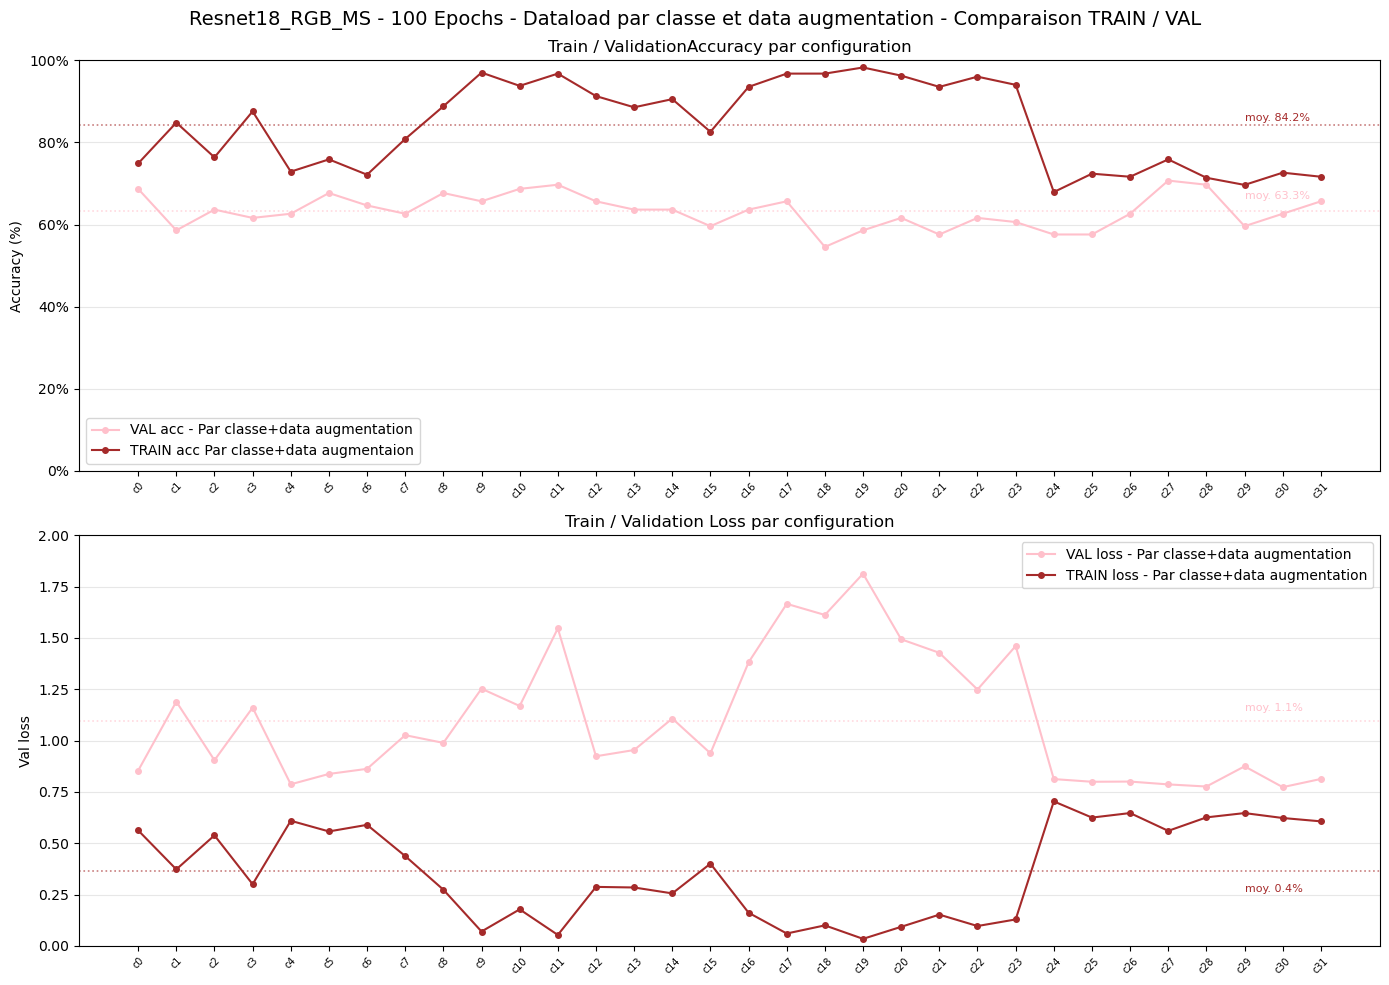

In [ ]:
labels = [f"c{i}" for i in range(len(grid_par_classe_aug_50))]

# --- Figure 1 : val_acc comparaison ---

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Resnet18_RGB_MS_HS - 100 Epochs - Dataload par classe et data augmentation - Comparaison TRAIN / VAL", fontsize=14)

ax1 = axes[0]
ax1.plot(labels, grid_par_classe_aug_100["val_acc"],  color="pink", linestyle="-",  marker="o", markersize=4, label="VAL acc - Par classe+data augmentation")
ax1.plot(labels, grid_par_classe_aug_100["train_acc"],  color="brown", linestyle="-",  marker="o", markersize=4, label="TRAIN acc Par classe+data augmentaion")
ax1.axhline(grid_par_classe_aug_100["val_acc"].mean(),  color="pink", linestyle=":", alpha=0.6, linewidth=1.2)
ax1.axhline(grid_par_classe_aug_100["train_acc"].mean(),  color="brown", linestyle=":", alpha=0.6, linewidth=1.2)
ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim(0, 100)
ax1.set_title("Train / ValidationAccuracy par configuration")
ax1.legend()
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45, fontsize=7)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax1.grid(axis="y", alpha=0.3)

# Annotations moyennes
ax1.annotate(f"moy. {grid_par_classe_aug_100['train_acc'].mean():.1f}%", xy=(31, grid_par_classe_aug_100["train_acc"].mean()),
             xytext=(29, grid_par_classe_aug_100["train_acc"].mean() + 1), color="brown", fontsize=8)
ax1.annotate(f"moy. {grid_par_classe_aug_100['val_acc'].mean():.1f}%", xy=(31, grid_par_classe_aug_100["val_acc"].mean()), #défini les coordonnées du graphique
             xytext=(29, grid_par_classe_aug_100["val_acc"].mean() + 3), color="pink", fontsize=8) #défini les coordonnées précises du graphique ou doit s'afficher le texte

# --- Figure 2 : val_loss comparaison ---
ax2 = axes[1]
ax2.plot(labels, grid_par_classe_aug_100["val_loss"],  color="pink", linestyle="-",  marker="o", markersize=4, label="VAL loss - Par classe+data augmentation")
ax2.plot(labels, grid_par_classe_aug_100["train_loss"],  color="brown", linestyle="-",  marker="o", markersize=4, label="TRAIN loss - Par classe+data augmentation")
ax2.axhline(grid_par_classe_aug_100["val_loss"].mean(),  color="pink", linestyle=":", alpha=0.6, linewidth=1.2)
ax2.axhline(grid_par_classe_aug_100["train_loss"].mean(),  color="brown", linestyle=":", alpha=0.6, linewidth=1.2)
ax2.set_ylabel("Val loss")
ax2.set_title("Train / Validation Loss par configuration")
ax2.legend()
ax2.set_ylim(0, 2.0)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, fontsize=7)
ax2.grid(axis="y", alpha=0.3)

# Annotations moyennes
ax2.annotate(f"moy. {grid_par_classe_aug_100['train_loss'].mean():.1f}%", xy=(31, grid_par_classe_aug_100["train_loss"].mean()),
             xytext=(29, grid_par_classe_aug_100["train_loss"].mean() - 0.1 ), color="brown", fontsize=8)
ax2.annotate(f"moy. {grid_par_classe_aug_100['val_loss'].mean():.1f}%", xy=(31, grid_par_classe_aug_100["val_loss"].mean()), #défini les coordonnées du graphique
             xytext=(29, grid_par_classe_aug_100["val_loss"].mean() + 0.05), color="pink", fontsize=8) #défini les coordonnées précises du graphique ou doit s'afficher le texte


plt.tight_layout()
plt.savefig("figures/comparison_val_metrics_100_epochs_18_RGB_MS_HS.png", dpi=150, bbox_inches="tight")
plt.show()


In [15]:
summary = pd.DataFrame({
    "Méthode":         ["Par classe+data augmentation - 50 epochs", "Par classe+data augmentation - 100 epochs"],
    "Val acc max":     [grid_par_classe_aug_50["val_acc"].max(), grid_par_classe_aug_100["val_acc"].max()],
    "Val acc moy":     [grid_par_classe_aug_50["val_acc"].mean(), grid_par_classe_aug_100["val_acc"].mean()],
    "Val loss min":    [grid_par_classe_aug_50["val_loss"].min(), grid_par_classe_aug_100["val_loss"].min()],
    "Val loss moy":    [grid_par_classe_aug_50["val_loss"].mean(), grid_par_classe_aug_100["val_loss"].mean()]

})
print(summary.to_string(index=False))



                                  Méthode  Val acc max  Val acc moy  Val loss min  Val loss moy
 Par classe+data augmentation - 50 epochs    75.757576    66.477273      0.701687      0.819358
Par classe+data augmentation - 100 epochs    74.747475    66.824495      0.710572      0.892908


In [17]:
#Meileur sans overfitting 50 et 100 epochs confondues
# Création de la colonne SGD lr 0,0001
# Filtrer SGD + lr=0.0001

mask = (
    (grid_par_classe_aug['optimizer'] == 'SGD') &
    (grid_par_classe_aug['config'].str.contains('lr0.0001'))
)

sgd_lr_filtered = grid_par_classe_aug[mask]

# Meilleure config selon f1_macro
best = sgd_lr_filtered.loc[sgd_lr_filtered['f1_macro'].idxmax()]
print(best[['config', 'val_acc', 'val_loss', 'f1_macro', 'f1_Health', 'f1_Rust', 'f1_Other']])


best.to_frame().T.to_csv('best_sgd_lr0001_18_RGB_MS_HS.csv', index=False)


config       config58_epochs100_lr0.0001_optSGD_schedStepLR...
val_acc                                              73.737374
val_loss                                              0.710572
f1_macro                                              0.662219
f1_Health                                              0.44898
f1_Rust                                               0.731707
f1_Other                                               0.80597
Name: 58, dtype: object


In [26]:
def best_config_val_acc(df):
    return df.loc[df["val_acc"].idxmax(), "config"]

def best_config_val_loss(df):
    return df.loc[df["val_loss"].idxmin(), "config"]

def best_config_F1(df):
    return df.loc[df["f1_macro"].idxmax(), "config"]

summary_100 = pd.DataFrame({
    "Méthode": [
        "Par classe + data aug"
    ],
    "Val acc max": [
        grid_par_classe_aug_100["val_acc"].max(),
    ],
    "Val acc moy": [
        grid_par_classe_aug_100["val_acc"].mean(),
    ],
    "Val loss min": [
        grid_par_classe_aug_100["val_loss"].min(),
    ],
    "Val loss moy": [
        grid_par_classe_aug_100["val_loss"].mean(),
    ],

     "F1 macro max": [
    grid_par_classe_aug_100["f1_macro"].max(),
    ],

    "Meilleure config (val_acc)": [
        best_config_val_acc(grid_par_classe_aug_100),
    ],

       "Meilleure config (val_loss)": [
        best_config_val_loss(grid_par_classe_aug_100),
    ],

     "Meilleure config (f1_macro)": [
        best_config_F1(grid_par_classe_aug_100),
    ],
   
})

print(summary_100.to_string(index=False))

              Méthode  Val acc max  Val acc moy  Val loss min  Val loss moy  F1 macro max                                     Meilleure config (val_acc)                                    Meilleure config (val_loss)                                    Meilleure config (f1_macro)
Par classe + data aug    74.747475    66.824495      0.710572      0.892908      0.662219 config32_epochs100_lr0.001_optAdam_schedStepLR_step20_gamma0.1 config58_epochs100_lr0.0001_optSGD_schedStepLR_step30_gamma0.1 config58_epochs100_lr0.0001_optSGD_schedStepLR_step30_gamma0.1
